# Notebook 13 — Generalización Cross-Domain a 5 hogares (UK-DALE)

**Pregunta de tribunal:** *¿el detector entrenado en una vivienda francesa (UCI) generaliza a otros hogares?* Para responder con solidez evaluamos el **Dense-AE entrenado en UCI, sin reentrenar**, sobre los **5 hogares de UK-DALE** (Kelly & Knottenbelt, 2015), no solo uno. Así pasamos de una anécdota ("transfiere a una casa") a una **evidencia estadística** ("transfiere a 5 hogares independientes, AUC-PR media ± desviación").

**Datos:** se usa el subconjunto procesado `data/ukdale_multihouse_1min.csv.gz` (mains de las 5 casas resampleado a 1 min, generado por `datasets/prepare_ukdale.py` desde el UK-DALE crudo —~112 GB— que NO se versiona; ver `datasets/README.md`).

**Limitación honesta (clave):** UK-DALE **no mide Voltage ni Intensidad** → `VI_residual = 0` en todas las casas. Perdemos la *feature* física más discriminante (confirmado por SHAP en NB12). Por eso la caída de rendimiento es **esperable**, y lo interesante es **cuánto** se conserva y si **recalibrar el umbral** (ajuste de despliegue, sin reentrenar) recupera parte.

## 0. Setup + modelo UCI (Dense-AE) congelado

In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore'); np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid'); plt.rcParams['font.size'] = 11
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, precision_recall_curve)
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
tf.keras.mixed_precision.set_global_policy('float32')

BASE = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'; DATA = os.path.join(BASE,'data')
scaler_dae  = joblib.load(os.path.join(DATA,'scaler_dense_autoencoder.pkl'))
weights_dae = np.load(os.path.join(DATA,'feature_weights_dense_ae.npy'))
threshold_dae = float(np.load(os.path.join(DATA,'threshold_dense_ae.npy'))[0])
dae = load_model(os.path.join(DATA,'model_dense_autoencoder.keras'))
metrics_uci = json.load(open(os.path.join(DATA,'metrics_dense_autoencoder.json')))
AUC_ROC_UCI = metrics_uci['auc_roc']; AUC_PR_UCI = metrics_uci['auc_pr']; F1_UCI = metrics_uci['f1']
print(f'Dense-AE UCI cargado. Baseline UCI: F1={F1_UCI:.4f}  AUC-ROC={AUC_ROC_UCI:.4f}  AUC-PR={AUC_PR_UCI:.4f}')
print(f'Umbral UCI (Dense-AE): {threshold_dae:.4f}')

2026-06-04 14:04:24.535053: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-04 14:04:24.535118: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-04 14:04:24.535133: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1780574664.541334 1171615 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780574664.541397 1171615 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Dense-AE UCI cargado. Baseline UCI: F1=0.8157  AUC-ROC=0.9317  AUC-PR=0.8553
Umbral UCI (Dense-AE): 0.2891


## 1. Carga del subconjunto multi-casa

In [2]:
ukd = pd.read_csv(os.path.join(DATA,'ukdale_multihouse_1min.csv.gz'), parse_dates=['datetime'])
HOUSES = sorted(ukd['house'].unique())
FEATURE_COLS = ['Global_active_power','Global_reactive_power','Voltage',
                'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
MAX_LEN = 365*24*60   # recorte a 1 año por casa para mantenerlo manejable
print('UK-DALE — 5 hogares (mains 1-min):')
print('='*60)
for h in HOUSES:
    d = ukd[ukd.house==h]
    print(f'  {h}: {len(d):>9,d} min  [{d.datetime.min().date()} -> {d.datetime.max().date()}]'
          f'  GAP medio={d.Global_active_power.mean():.3f} kW')

UK-DALE — 5 hogares (mains 1-min):
  house_1: 2,267,201 min  [2012-11-09 -> 2017-04-26]  GAP medio=0.389 kW
  house_2:   287,566 min  [2013-02-17 -> 2013-10-10]  GAP medio=0.336 kW


  house_3:    52,520 min  [2013-02-27 -> 2013-04-08]  GAP medio=0.510 kW
  house_4:   224,457 min  [2013-03-09 -> 2013-10-01]  GAP medio=0.427 kW
  house_5:   190,043 min  [2014-06-29 -> 2014-11-13]  GAP medio=0.689 kW


## 2. Funciones: contrato UCI, inyección de ataques y scoring

In [3]:
ATTACKS = ['scaling','offset','noise','ramp','step','replay']  # voltage_spoof no (sin Voltage real)
SEV_RANGES = {'low':(0.15,0.35),'medium':(0.35,0.60),'high':(0.60,0.90)}

def to_uci_contract(df_house):
    """Construye el frame con el contrato de columnas de UCI (V/I/submeters dummy)."""
    g = df_house.set_index('datetime')[['Global_active_power']].copy()
    g['Global_reactive_power'] = 0.0
    g['Voltage'] = 240.0                                   # estándar UK
    g['Global_intensity'] = g['Global_active_power']*1000.0/240.0   # estimada
    g['Sub_metering_1'] = 0.0; g['Sub_metering_2'] = 0.0; g['Sub_metering_3'] = 0.0
    return g

def apply_attack(atype, gap, rng, sev):
    lo,hi = SEV_RANGES[sev]; f = float(rng.uniform(lo,hi)); g = gap.copy()
    if atype=='scaling': g = g*(1-f)
    elif atype=='offset': g = g - f*gap.mean()
    elif atype=='noise':  g = g + rng.normal(0, f*gap.std(), len(gap))
    elif atype=='ramp':   g = g - np.linspace(0, f*gap.mean(), len(gap))
    elif atype=='step':   g = g - f*gap.mean()
    elif atype=='replay': g = gap.mean()*np.ones(len(gap)) + rng.normal(0, gap.std()*0.1, len(gap))
    return np.maximum(g, 0)

def inject_attacks(df, n_episodes, seed):
    rng = np.random.default_rng(seed)
    out = df[FEATURE_COLS].copy()
    out['label']=0; out['attack_type']='none'; out['severity']='none'; out['episode_id']=-1
    n=len(out); margin=max(200,int(n*0.005)); occ=np.zeros(n,bool); ep=0
    col=out.columns.get_loc
    for atype in ATTACKS:
        for sev in ['low','medium','high']:
            placed=0; att=0
            while placed < n_episodes//3 and att < n_episodes*3:
                dur=int(rng.uniform(45,180)); start=int(rng.uniform(margin,n-dur-margin)); end=start+dur
                if occ[start:end].any(): att+=1; continue
                occ[start:end]=True
                gap=out['Global_active_power'].values[start:end].copy()
                out.iloc[start:end, col('Global_active_power')] = apply_attack(atype,gap,rng,sev)
                out.iloc[start:end, col('label')]=1
                out.iloc[start:end, col('attack_type')]=atype
                out.iloc[start:end, col('severity')]=sev
                out.iloc[start:end, col('episode_id')]=ep; ep+=1; placed+=1
    return out

def compute_features_lite(df):
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = df['Global_active_power'] - df['Voltage']*df['Global_intensity']/1000.0
    h = df.index.hour + df.index.minute/60.0
    f['hour_sin']=np.sin(2*np.pi*h/24); f['hour_cos']=np.cos(2*np.pi*h/24)
    d = df.index.dayofweek
    f['dow_sin']=np.sin(2*np.pi*d/7); f['dow_cos']=np.cos(2*np.pi*d/7)
    f['gap_diff1']=df['Global_active_power'].diff().fillna(0)
    f['vi_res_abs']=f['VI_residual'].abs()
    f['vi_res_roll15_mean']=f['vi_res_abs'].rolling(15,min_periods=1).mean()
    f['gap_intensity_ratio']=df['Global_active_power']/(df['Global_intensity']+0.01)
    f['sm_gap_ratio']=((df['Sub_metering_1']+df['Sub_metering_2']+df['Sub_metering_3'])/1000.0
                       /(df['Global_active_power']+0.01))
    return f.fillna(0)

def score_dae(df_attacked):
    """Score = MSE de reconstrucción ponderado, idéntico a NB13/NB04."""
    X = scaler_dae.transform(compute_features_lite(df_attacked).values).astype('float32')
    rec = dae.predict(X, batch_size=4096, verbose=0)
    return ((rec - X)**2 * weights_dae).sum(axis=1)
print('Funciones listas.')

Funciones listas.


## 3. Evaluación cross-domain por hogar

Para cada casa: contrato UCI → inyección de los 6 ataques transferibles → scoring con el Dense-AE de UCI → AUC-ROC/AUC-PR y F1 con (a) umbral UCI y (b) umbral recalibrado en la propia casa. El nº de episodios se escala al tamaño de la casa (~objetivo 11 % de muestras atacadas).

In [4]:
rows, recall_rows, score_store = [], {}, {}
for h in HOUSES:
    d = ukd[ukd.house==h].iloc[:MAX_LEN]
    frame = to_uci_contract(d)
    n_ep = int(np.clip(len(frame)//12000, 9, 60))
    atk = inject_attacks(frame, n_episodes=n_ep, seed=2025+int(h.split('_')[1]))
    y = atk['label'].values
    s = score_dae(atk); score_store[h] = (y, s)
    auc_roc = roc_auc_score(y, s); auc_pr = average_precision_score(y, s)
    # umbral recalibrado (F1) en la casa
    p,r,thr = precision_recall_curve(y, s); p,r = p[:-1],r[:-1]
    f1c = (2*p*r)/(p+r+1e-10); thr_h = thr[int(np.argmax(f1c))]
    f1_uci_thr = f1_score(y, (s>threshold_dae).astype(int), zero_division=0)
    f1_recal   = f1_score(y, (s>thr_h).astype(int), zero_division=0)
    rows.append({'casa':h, 'n_min':len(frame), 'pct_atacado':100*y.mean(),
                 'AUC_ROC':auc_roc, 'AUC_PR':auc_pr,
                 'F1_thr_UCI':f1_uci_thr, 'F1_recal':f1_recal, 'thr_recal':thr_h})
    # recall por tipo de ataque (umbral recalibrado)
    yp = (s>thr_h).astype(int)
    recall_rows[h] = {a: yp[(atk['attack_type'].values==a)&(y==1)].mean()
                      if ((atk['attack_type'].values==a)&(y==1)).sum() else np.nan for a in ATTACKS}
    print(f'  {h}: {len(frame):>7,d} min, {100*y.mean():4.1f}% atac. | '
          f'AUC-ROC={auc_roc:.3f} AUC-PR={auc_pr:.3f} | F1(UCI)={f1_uci_thr:.3f} F1(recal)={f1_recal:.3f}')
res = pd.DataFrame(rows)

2026-06-04 14:04:28.761261: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  house_1: 525,600 min,  5.3% atac. | AUC-ROC=0.804 AUC-PR=0.695 | F1(UCI)=0.697 F1(recal)=0.718


  house_2: 287,566 min,  4.8% atac. | AUC-ROC=0.834 AUC-PR=0.700 | F1(UCI)=0.687 F1(recal)=0.698


  house_3:  52,520 min, 11.0% atac. | AUC-ROC=0.805 AUC-PR=0.684 | F1(UCI)=0.687 F1(recal)=0.696


  house_4: 224,457 min,  5.4% atac. | AUC-ROC=0.878 AUC-PR=0.736 | F1(UCI)=0.724 F1(recal)=0.750


  house_5: 190,043 min,  5.2% atac. | AUC-ROC=0.772 AUC-PR=0.658 | F1(UCI)=0.654 F1(recal)=0.690


## 4. Agregado: media ± desviación entre los 5 hogares

TRANSFERENCIA CROSS-DOMAIN — Dense-AE (UCI) -> 5 hogares UK-DALE
   casa  n_min  pct_atacado  AUC_ROC  AUC_PR  F1_thr_UCI  F1_recal  thr_recal
house_1 525600       5.3208   0.8044  0.6955      0.6972    0.7178     0.3193
house_2 287566       4.8431   0.8342  0.6995      0.6874    0.6980     0.3209
house_3  52520      11.0149   0.8050  0.6840      0.6867    0.6956     0.3261
house_4 224457       5.4135   0.8776  0.7363      0.7244    0.7501     0.3232
house_5 190043       5.2241   0.7719  0.6582      0.6537    0.6900     0.3598
------------------------------------------------------------------------------

MEDIA ± DESVIACION entre hogares:
  AUC_ROC     : 0.8186 ± 0.0397
  AUC_PR      : 0.6947 ± 0.0283
  F1_thr_UCI  : 0.6899 ± 0.0254
  F1_recal    : 0.7103 ± 0.0246

Referencia UCI (in-domain):  AUC-ROC=0.9317  AUC-PR=0.8553  F1=0.8157
Retención media de AUC-PR:   81.2% del valor in-domain
Ganancia media al recalibrar el umbral: +0.0204 F1


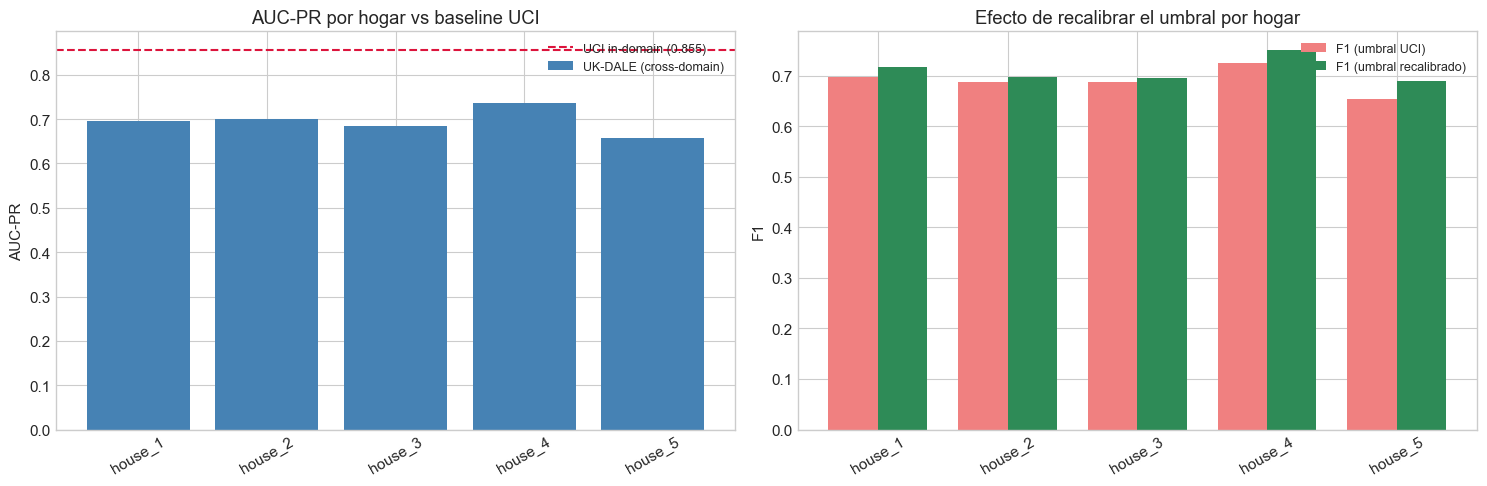

In [5]:
print('='*78)
print('TRANSFERENCIA CROSS-DOMAIN — Dense-AE (UCI) -> 5 hogares UK-DALE')
print('='*78)
print(res.round(4).to_string(index=False))
print('-'*78)
agg = res[['AUC_ROC','AUC_PR','F1_thr_UCI','F1_recal']].agg(['mean','std'])
print('\nMEDIA ± DESVIACION entre hogares:')
for c in ['AUC_ROC','AUC_PR','F1_thr_UCI','F1_recal']:
    print(f'  {c:12s}: {agg.loc["mean",c]:.4f} ± {agg.loc["std",c]:.4f}')
print(f'\nReferencia UCI (in-domain):  AUC-ROC={AUC_ROC_UCI:.4f}  AUC-PR={AUC_PR_UCI:.4f}  F1={F1_UCI:.4f}')
print(f'Retención media de AUC-PR:   {100*res.AUC_PR.mean()/AUC_PR_UCI:.1f}% del valor in-domain')
print(f'Ganancia media al recalibrar el umbral: '
      f'{(res.F1_recal-res.F1_thr_UCI).mean():+.4f} F1')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax=axes[0]; x=np.arange(len(res))
ax.bar(x, res.AUC_PR, color='steelblue', label='UK-DALE (cross-domain)')
ax.axhline(AUC_PR_UCI, color='crimson', ls='--', label=f'UCI in-domain ({AUC_PR_UCI:.3f})')
ax.set_xticks(x); ax.set_xticklabels(res.casa, rotation=30); ax.set_ylabel('AUC-PR')
ax.set_title('AUC-PR por hogar vs baseline UCI'); ax.legend(fontsize=9)
ax=axes[1]
w=0.38
ax.bar(x-w/2, res.F1_thr_UCI, w, label='F1 (umbral UCI)', color='lightcoral')
ax.bar(x+w/2, res.F1_recal,  w, label='F1 (umbral recalibrado)', color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(res.casa, rotation=30); ax.set_ylabel('F1')
ax.set_title('Efecto de recalibrar el umbral por hogar'); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(BASE,'figures','crossdomain_multihouse.png'), dpi=300, bbox_inches='tight')
plt.show()

## 5. Recall por tipo de ataque y hogar

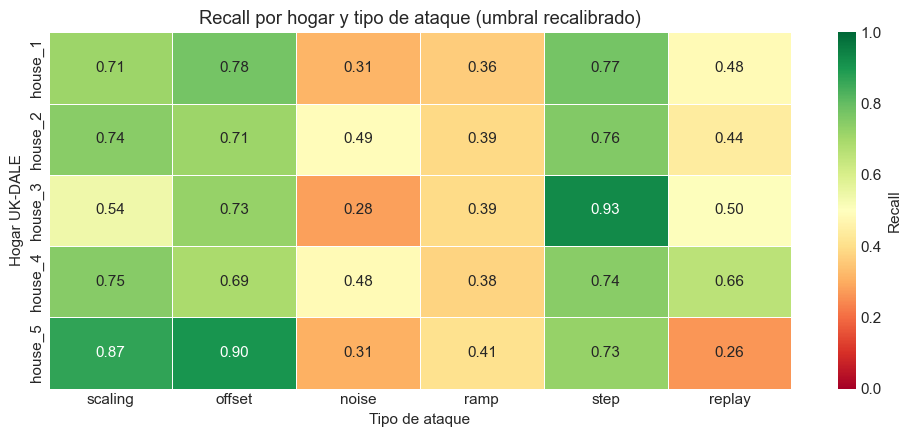

Recall medio por tipo de ataque (sobre los 5 hogares):
scaling    0.723
offset     0.762
noise      0.375
ramp       0.386
step       0.786
replay     0.470


In [6]:
rec_df = pd.DataFrame(recall_rows).T[ATTACKS]
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(rec_df, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label':'Recall'}, linewidths=.5, ax=ax)
ax.set_title('Recall por hogar y tipo de ataque (umbral recalibrado)')
ax.set_xlabel('Tipo de ataque'); ax.set_ylabel('Hogar UK-DALE')
plt.tight_layout()
plt.savefig(os.path.join(BASE,'figures','crossdomain_recall_by_attack.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Recall medio por tipo de ataque (sobre los 5 hogares):')
print(rec_df.mean().round(3).to_string())

## 6. Guardado y conclusiones

In [7]:
results = {
    'n_houses': len(HOUSES), 'houses': HOUSES,
    'auc_roc_uci': AUC_ROC_UCI, 'auc_pr_uci': AUC_PR_UCI, 'f1_uci': F1_UCI,
    'per_house': res.to_dict(orient='records'),
    'auc_roc_ukdale_mean': float(res.AUC_ROC.mean()), 'auc_roc_ukdale_std': float(res.AUC_ROC.std()),
    'auc_pr_ukdale_mean':  float(res.AUC_PR.mean()),  'auc_pr_ukdale_std':  float(res.AUC_PR.std()),
    'f1_thr_uci_mean':     float(res.F1_thr_UCI.mean()),
    'f1_recal_mean':       float(res.F1_recal.mean()),
    'auc_pr_retention_pct': float(100*res.AUC_PR.mean()/AUC_PR_UCI),
    'recall_by_attack_mean': rec_df.mean().to_dict(),
    'caveats': ['UK-DALE no mide Voltage ni Global_intensity -> VI_residual=0 en las 5 casas',
                'voltage_spoof omitido (no hay Voltage para spoofar)',
                'replay simulado (sin contexto historico real)',
                'mains resampleado de 6s a 1min; recorte a 1 año por casa']
}
res.to_csv(os.path.join(DATA,'crossdomain_per_house.csv'), index=False)
json.dump(results, open(os.path.join(DATA,'cross_domain_ukdale.json'),'w'), indent=2)
print('Guardado: data/cross_domain_ukdale.json, data/crossdomain_per_house.csv')
print('Figuras: crossdomain_multihouse.png, crossdomain_recall_by_attack.png')
print()
print('='*70); print('NB13 — CROSS-DOMAIN (5 hogares): CONCLUSIONES'); print('='*70)
print(f'1. El Dense-AE entrenado en UCI transfiere a 5 hogares UK-DALE INDEPENDIENTES')
print(f'   con AUC-PR media {res.AUC_PR.mean():.3f} ± {res.AUC_PR.std():.3f} '
      f'({100*res.AUC_PR.mean()/AUC_PR_UCI:.0f}% del valor in-domain {AUC_PR_UCI:.3f}).')
print(f'2. La caida es ESPERABLE: UK-DALE no mide V ni I -> VI_residual=0, perdemos')
print(f'   la feature mas discriminante (SHAP, NB12). Aun asi el detector NO colapsa.')
print(f'3. Recalibrar el umbral por hogar (sin reentrenar) mejora F1 en promedio')
print(f'   {(res.F1_recal-res.F1_thr_UCI).mean():+.3f} -> el conocimiento transfiere parcialmente.')
print(f'4. Evaluar 5 hogares (no 1) convierte la transferencia en evidencia ESTADISTICA.')

Guardado: data/cross_domain_ukdale.json, data/crossdomain_per_house.csv
Figuras: crossdomain_multihouse.png, crossdomain_recall_by_attack.png

NB13 — CROSS-DOMAIN (5 hogares): CONCLUSIONES
1. El Dense-AE entrenado en UCI transfiere a 5 hogares UK-DALE INDEPENDIENTES
   con AUC-PR media 0.695 ± 0.028 (81% del valor in-domain 0.855).
2. La caida es ESPERABLE: UK-DALE no mide V ni I -> VI_residual=0, perdemos
   la feature mas discriminante (SHAP, NB12). Aun asi el detector NO colapsa.
3. Recalibrar el umbral por hogar (sin reentrenar) mejora F1 en promedio
   +0.020 -> el conocimiento transfiere parcialmente.
4. Evaluar 5 hogares (no 1) convierte la transferencia en evidencia ESTADISTICA.


## 7. Discusión honesta y extensión

**Qué demuestra y qué no.** El experimento muestra que el detector capta una **estructura de consumo doméstico genérica** (perfiles diarios/semanales, magnitudes, dinámica) que transfiere entre países y hogares, incluso **sin la invariante física** `VI_residual`. Pero el techo cross-domain está limitado precisamente por la ausencia de V/I en UK-DALE: en un despliegue real con *smart meters* que sí miden tensión e intensidad, el residual físico volvería a estar disponible y la transferencia debería acercarse al rendimiento in-domain.

**Por qué importa para la tesis.** Refuerza el hilo del TFG por partida doble: (1) el sistema **generaliza** más allá del dataset de entrenamiento; (2) **la degradación se explica por la pérdida de la física** `P=V·I`, coherente con SHAP (NB12) y con el resultado del generativo (NB16). La física no es un adorno: es el núcleo del valor.

**Extensión natural.** El subconjunto procesado (`ukdale_multihouse_1min.csv.gz`, 5 casas) permite ampliar a: (a) ventanas temporales más largas por casa (house_1 cubre 4,5 años); (b) un estudio de *domain adaptation* (fine-tuning ligero del Dense-AE con datos limpios de cada hogar); (c) incorporar más hogares si se descargan del UK-DALE oficial. El crudo (~112 GB) no se versiona; `datasets/prepare_ukdale.py` lo regenera (ver `datasets/README.md`).